<a href="https://colab.research.google.com/github/Rupasri0105/23CSBTB30/blob/main/tripadvisor_hotel_reviews_1918.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LOADING DATASET

In [ ]:
import pandas as pd
df = pd.read_csv("/content/tripadvisor_hotel_reviews.csv", engine='python', on_bad_lines='skip')
print(df.head())
reviews = df["Review"]

                                              Review  Rating
0  nice hotel expensive parking got good deal sta...       4
1  ok nothing special charge diamond member hilto...       2
2  nice rooms not 4* experience hotel monaco seat...       3
3  unique, great stay, wonderful time hotel monac...       5
4  great stay great stay, went seahawk game aweso...       5


First 10 rows of text

In [ ]:
print(df["Review"].head(10))

0    nice hotel expensive parking got good deal sta...
1    ok nothing special charge diamond member hilto...
2    nice rooms not 4* experience hotel monaco seat...
3    unique, great stay, wonderful time hotel monac...
4    great stay great stay, went seahawk game aweso...
5    love monaco staff husband stayed hotel crazy w...
6    cozy stay rainy city, husband spent 7 nights m...
7    excellent staff, housekeeping quality hotel ch...
8    hotel stayed hotel monaco cruise, rooms genero...
9    excellent stayed hotel monaco past w/e delight...
Name: Review, dtype: object


**PREPROCESSING** :cleaning and preparing text data for analysis or modeling


Noisy rows : Data that contains errors, irrelevant information, or random variations, making it unreliable or hard to analyze.

In [ ]:
import nltk

In [ ]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Remove noisy characters and lowercase
noisy_chars = ["\n", "•", "@", "#", "%", "$"]
df['clean_text'] = df['Review'].astype(str).str.lower()
for ch in noisy_chars:
    df['clean_text'] = df['clean_text'].str.replace(ch, '', regex=False)
from nltk.tokenize import word_tokenize #
df['clean_tokens'] = df['clean_text'].apply(lambda x: word_tokenize(x))
print(df['clean_tokens'])

0        [nice, hotel, expensive, parking, got, good, d...
1        [ok, nothing, special, charge, diamond, member...
2        [nice, rooms, not, 4, *, experience, hotel, mo...
3        [unique, ,, great, stay, ,, wonderful, time, h...
4        [great, stay, great, stay, ,, went, seahawk, g...
                               ...                        
20486    [best, kept, secret, 3rd, time, staying, charm...
20487    [great, location, price, view, hotel, great, q...
20488    [ok, just, looks, nice, modern, outside, ,, de...
20489    [hotel, theft, ruined, vacation, hotel, opened...
20490    [people, talking, ,, ca, n't, believe, excelle...
Name: clean_tokens, Length: 20491, dtype: object


Stop words : Common words ignored in text analysis as they add little meaning.

In [ ]:
from nltk.corpus import stopwords

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['clean_tokens_no_stopwords'] = df['clean_tokens'].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

# ✅ Display the first few rows to see the result
print(df['clean_tokens_no_stopwords'].head(10))



0    [nice, hotel, expensive, parking, got, good, d...
1    [ok, nothing, special, charge, diamond, member...
2    [nice, rooms, 4, *, experience, hotel, monaco,...
3    [unique, ,, great, stay, ,, wonderful, time, h...
4    [great, stay, great, stay, ,, went, seahawk, g...
5    [love, monaco, staff, husband, stayed, hotel, ...
6    [cozy, stay, rainy, city, ,, husband, spent, 7...
7    [excellent, staff, ,, housekeeping, quality, h...
8    [hotel, stayed, hotel, monaco, cruise, ,, room...
9    [excellent, stayed, hotel, monaco, past, w/e, ...
Name: clean_tokens_no_stopwords, dtype: object


Stemming

In [ ]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('wordnet')
df['clean_tokens'] = df['clean_text'].apply(lambda x: word_tokenize(str(x)))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
sample_texts = df['clean_tokens'].head()
comparison = []
for tokens in sample_texts:
    stemmed = [stemmer.stem(w) for w in tokens]
    lemmatized = [lemmatizer.lemmatize(w) for w in tokens]
    comparison.append([" ".join(tokens), " ".join(stemmed), " ".join(lemmatized)])
comparison_df = pd.DataFrame(comparison, columns=["Original", "Stemmed", "Lemmatized"])
print(comparison_df)

[nltk_data] Downloading package wordnet to /root/nltk_data...


                                            Original  \
0  nice hotel expensive parking got good deal sta...   
1  ok nothing special charge diamond member hilto...   
2  nice rooms not 4 * experience hotel monaco sea...   
3  unique , great stay , wonderful time hotel mon...   
4  great stay great stay , went seahawk game awes...   

                                             Stemmed  \
0  nice hotel expens park got good deal stay hote...   
1  ok noth special charg diamond member hilton de...   
2  nice room not 4 * experi hotel monaco seattl g...   
3  uniqu , great stay , wonder time hotel monaco ...   
4  great stay great stay , went seahawk game awes...   

                                          Lemmatized  
0  nice hotel expensive parking got good deal sta...  
1  ok nothing special charge diamond member hilto...  
2  nice room not 4 * experience hotel monaco seat...  
3  unique , great stay , wonderful time hotel mon...  
4  great stay great stay , went seahawk game awes..

**TFIDF**:
TF = how often a word appears in a document.
IDF = how rare that word is across all documents.
So TF-IDF gives each word a weight.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
y = df['Rating'].astype(int) - 1
X = df['clean_text']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf_vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_text)

In [ ]:
y = df["Rating"].astype(int) - 1
X = df["clean_text"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ======================================================
# 5️⃣ TF-IDF VECTORIZATION (fit only on training data)
# ======================================================
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words="english"
)


X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)


X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print("TF-IDF shapes:", X_train_tfidf.shape, X_test_tfidf.shape)

TF-IDF shapes: (16392, 10000) (4099, 10000)


**Exploratory Analysis**

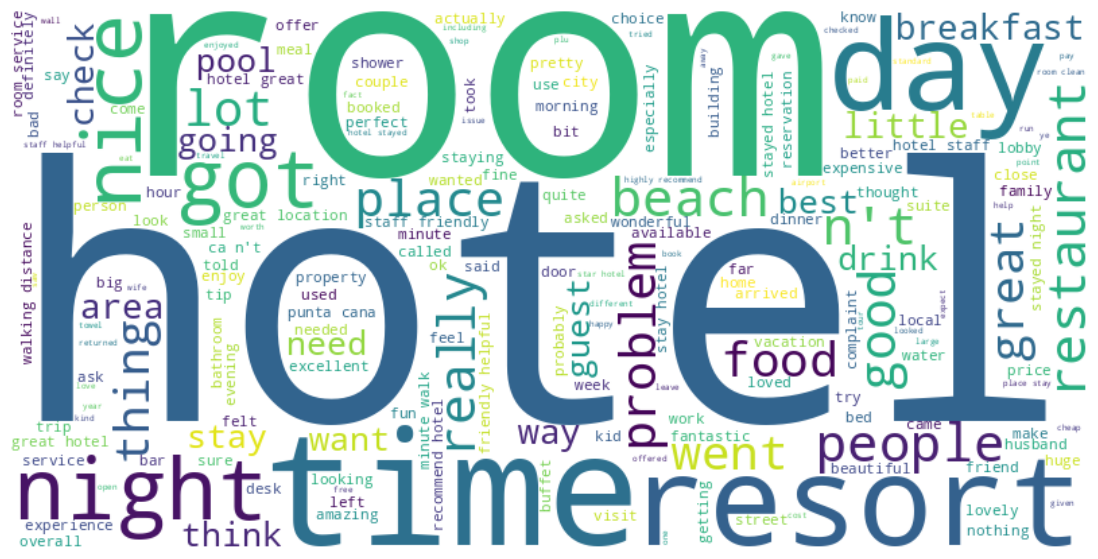

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
all_words = [word for tokens in df['clean_tokens'] for word in tokens]
wc = WordCloud(width=800, height=400, background_color="white").generate(" ".join(all_words))
plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
from nltk import ngrams
from collections import Counter
import pandas as pd
all_words = [word for tokens in df['clean_tokens'] for word in tokens]
bigrams = list(ngrams(all_words, 2))
bigram_freq = Counter(bigrams).most_common(10)
bigram_df = pd.DataFrame(bigram_freq, columns=["Bigram", "Count"])
print(bigram_df)

       Bigram  Count
0  (hotel, ,)   6679
1   (,, room)   6417
2  (,, hotel)   6340
3  (,, great)   5691
4    (,, not)   5143
5  (did, n't)   5109
6  (,, staff)   4678
7   (stay, ,)   3761
8  (did, not)   3746
9   (room, ,)   3707


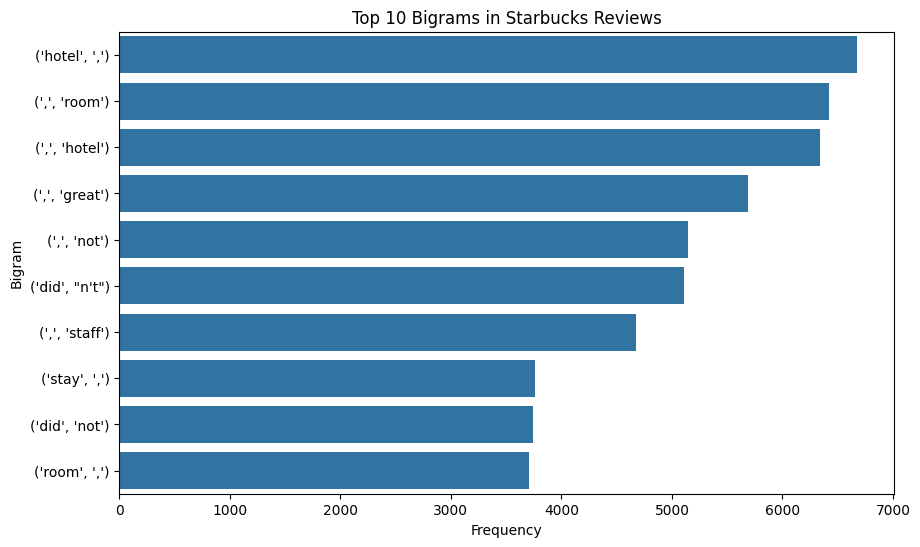

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(x="Count", y="Bigram", data=bigram_df.astype({"Bigram": str}))
plt.title("Top 10 Bigrams in Starbucks Reviews")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.show()

Feature Engineering

In [ ]:
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
import string

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer

# Use the already split data
X_train = X_train_text
X_test = X_test_text
# y_train and y_test are already correctly defined

# After splitting, fit CountVectorizer on X_train and transform both X_train and X_test
cr = CountVectorizer()
X_train_cv = cr.fit_transform(X_train)
X_test_cv = cr.transform(X_test)


lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_cv, y_train) # Train Logistic Regression after splitting and vectorizing
y_pred_lr = lr.predict(X_test_cv)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_cv, y_train)
y_pred_rf = rf.predict(X_test_cv)

# Print classification reports
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.65      0.65      0.65       284
           1       0.43      0.40      0.42       359
           2       0.34      0.29      0.31       437
           3       0.48      0.47      0.48      1208
           4       0.70      0.74      0.72      1811

    accuracy                           0.58      4099
   macro avg       0.52      0.51      0.51      4099
weighted avg       0.57      0.58      0.57      4099

Random Forest Report:
               precision    recall  f1-score   support

           0       0.82      0.44      0.57       284
           1       0.41      0.03      0.05       359
           2       0.67      0.01      0.02       437
           3       0.38      0.29      0.33      1208
           4       0.56      0.92      0.70      1811

    accuracy                           0.53      4099
   macro avg       0.57      0.34      0.33      4099
weighted avg       0.52  

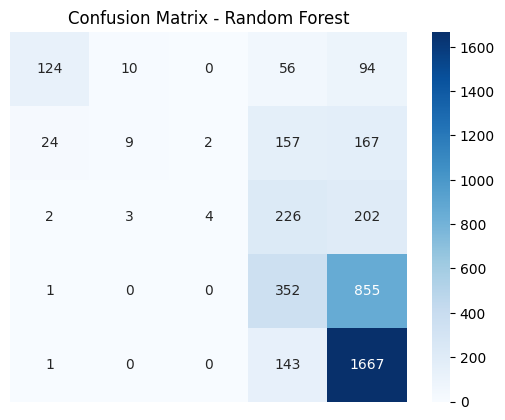

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[], yticklabels=[])
plt.title("Confusion Matrix - Random Forest")
plt.show()

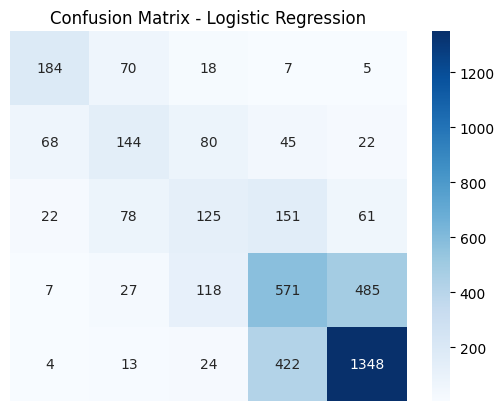

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[], yticklabels=[])
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**NEURAL NETWORKS**

In [ ]:
import tensorflow as tf

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding,Conv1D,GlobalMaxPooling1D,LSTM,Bidirectional
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split # This import is not strictly needed here but kept for clarity

# Define the model using Input (recommended)
mlp = Sequential([
    Input(shape=(X_train_tfidf.shape[1],)), # Use X_train_tfidf shape
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax') # Changed to 5 units for multi-class and softmax activation
])

# Compile
# Use 'sparse_categorical_crossentropy' for integer labels in multi-class classification
mlp.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train using the already split data X_train_tfidf and X_test_tfidf
history = mlp.fit(X_train_tfidf.toarray(), y_train, epochs=5, batch_size=64, validation_split=0.1)

Epoch 1/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.4740 - loss: 1.2624 - val_accuracy: 0.6360 - val_loss: 0.8068
Epoch 2/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7356 - loss: 0.6527 - val_accuracy: 0.6402 - val_loss: 0.8200
Epoch 3/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8411 - loss: 0.4458 - val_accuracy: 0.6055 - val_loss: 0.9354
Epoch 4/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9174 - loss: 0.2714 - val_accuracy: 0.6012 - val_loss: 1.1607
Epoch 5/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9592 - loss: 0.1514 - val_accuracy: 0.5921 - val_loss: 1.4355


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import pandas as pd
import numpy as np

# Predict probabilities
y_pred_proba = mlp.predict(X_test_tfidf.toarray())

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_proba, axis=1)

# Accuracy
acc = accuracy_score(y_test, y_pred)

# Precision, Recall, F1-score (use 'weighted' or 'macro' for multi-class)
p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted') # Changed average to 'weighted' for multi-class

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Create a results table
results = pd.DataFrame([{
    "Model": "MLP_TFIDF",
    "Accuracy": acc,
    "Precision": p,
    "Recall": r,
    "F1-score": f1
}])

print("\n=== Evaluation Table ===")
print(results.round(4))

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

Classification Report:
              precision    recall  f1-score   support

           0     0.6517    0.6655    0.6585       284
           1     0.3857    0.3900    0.3878       359
           2     0.3881    0.2975    0.3368       437
           3     0.4911    0.4785    0.4847      1208
           4     0.7094    0.7576    0.7327      1811

    accuracy                         0.5877      4099
   macro avg     0.5252    0.5178    0.5201      4099
weighted avg     0.5785    0.5877    0.5821      4099


=== Evaluation Table ===
       Model  Accuracy  Precision  Recall  F1-score
0  MLP_TFIDF    0.5877     0.5785  0.5877    0.5821


**CNN**

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])
padded_sequences = pad_sequences(sequences, maxlen=100)
vocab_size = len(tokenizer.word_index) + 1
# Use df['Rating'] as the target and adjust labels to be 0-indexed
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(padded_sequences, df['Rating'].astype(int) - 1, test_size=0.2, random_state=42)
cnn=Sequential([
Embedding(vocab_size,128,input_length=100),
Conv1D(64,5,activation='relu'),
GlobalMaxPooling1D(),
Dense(64,activation='relu'),
# Change to 5 units for multi-class classification and use softmax activation
Dense(5,activation='softmax')
])
# Use sparse_categorical_crossentropy for integer labels in multi-class classification
cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
cnn.fit(X_train_seq,y_train_seq,validation_data=(X_test_seq,y_test_seq),epochs=5,batch_size=64)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


257/257 ━━━━━━━━━━━━━━━━━━━━ 41s 138ms/step - accuracy: 0.4627 - loss: 1.3055 - val_accuracy: 0.5901 - val_loss: 0.9497
Epoch 2/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 36s 120ms/step - accuracy: 0.6548 - loss: 0.8276 - val_accuracy: 0.6250 - val_loss: 0.8783
Epoch 3/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 33s 127ms/step - accuracy: 0.8367 - loss: 0.4929 - val_accuracy: 0.6116 - val_loss: 0.9589
Epoch 4/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 31s 121ms/step - accuracy: 0.9562 - loss: 0.1958 - val_accuracy: 0.6048 - val_loss: 1.2492
Epoch 5/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 31s 121ms/step - accuracy: 0.9932 - loss: 0.0591 - val_accuracy: 0.5953 - val_loss: 1.3776


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import pandas as pd
import numpy as np

# Predict
y_pred_proba_cnn = cnn.predict(X_test_seq)
y_pred_cnn = np.argmax(y_pred_proba_cnn, axis=1)

# Compute metrics
acc = accuracy_score(y_test_seq, y_pred_cnn)
# Use 'weighted' or 'macro' for multi-class classification
p, r, f1, _ = precision_recall_fscore_support(y_test_seq, y_pred_cnn, average='weighted')

# Print classification report
print("\nCNN Classification Report:")
print(classification_report(y_test_seq, y_pred_cnn, digits=4))

# Store results in a DataFrame
results_cnn = pd.DataFrame([{
    "Model": "CNN_embeddings",
    "Accuracy": acc,
    "Precision": p,
    "Recall": r,
    "F1-score": f1
}])

print("\n=== CNN Evaluation Table ===")
print(results_cnn.round(4))

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

CNN Classification Report:
              precision    recall  f1-score   support

           0     0.6923    0.4623    0.5544       292
           1     0.3529    0.4505    0.3958       333
           2     0.3976    0.3102    0.3485       432
           3     0.5342    0.5176    0.5258      1252
           4     0.7118    0.7670    0.7384      1790

    accuracy                         0.5953      4099
   macro avg     0.5378    0.5015    0.5126      4099
weighted avg     0.5939    0.5953    0.5914      4099


=== CNN Evaluation Table ===
            Model  Accuracy  Precision  Recall  F1-score
0  CNN_embeddings    0.5953     0.5939  0.5953    0.5914


**LSTM**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import pandas as pd
import numpy as np

# Define the BiLSTM model
bilstm = Sequential([
    Embedding(vocab_size, 128, input_length=100),
    Bidirectional(LSTM(64)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    # Change to 5 units for multi-class classification and use softmax activation
    Dense(5, activation='softmax')
])
bilstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("Training BiLSTM model...")
history_lstm = bilstm.fit(X_train_seq, y_train_seq, epochs=5, batch_size=64, validation_data=(X_test_seq, y_test_seq))
print("BiLSTM model training finished.")

# Predict using BiLSTM
y_pred_proba_lstm = bilstm.predict(X_test_seq)
y_pred_lstm = np.argmax(y_pred_proba_lstm, axis=1)

# Compute metrics
acc = accuracy_score(y_test_seq, y_pred_lstm)
# Use 'weighted' or 'macro' for multi-class classification
p, r, f1, _ = precision_recall_fscore_support(y_test_seq, y_pred_lstm, average='weighted')

# Print classification report
print("\nBiLSTM Classification Report:")
print(classification_report(y_test_seq, y_pred_lstm, digits=4))

# Store results in a DataFrame
results_lstm = pd.DataFrame([{
    "Model": "BiLSTM_embeddings",
    "Accuracy": acc,
    "Precision": p,
    "Recall": r,
    "F1-score": f1
}])

# Print results table
print("\n=== BiLSTM Evaluation Table ===")
print(results_lstm.round(4))

Training BiLSTM model...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


257/257 ━━━━━━━━━━━━━━━━━━━━ 95s 346ms/step - accuracy: 0.4525 - loss: 1.2715 - val_accuracy: 0.5518 - val_loss: 0.9911
Epoch 2/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 139s 334ms/step - accuracy: 0.6147 - loss: 0.8564 - val_accuracy: 0.5982 - val_loss: 0.9386
Epoch 3/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 84s 328ms/step - accuracy: 0.7415 - loss: 0.6286 - val_accuracy: 0.5709 - val_loss: 1.0428
Epoch 4/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 139s 318ms/step - accuracy: 0.8276 - loss: 0.4583 - val_accuracy: 0.5521 - val_loss: 1.1964
Epoch 5/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 320ms/step - accuracy: 0.8899 - loss: 0.3159 - val_accuracy: 0.5482 - val_loss: 1.5153
BiLSTM model training finished.
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step

BiLSTM Classification Report:
              precision    recall  f1-score   support

           0     0.7198    0.4486    0.5527       292
           1     0.4043    0.2853    0.3345       333
           2     0.3145    0.4259    0.3618       432
           3     0.4481    0.5000   

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
import numpy as np
# Define the BiLSTM model
lstm = Sequential([
    Embedding(vocab_size, 128, input_length=100),
    Bidirectional(LSTM(64)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    # Change to 5 units for multi-class classification and use softmax activation
    Dense(5, activation='softmax')
])
lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("Training BiLSTM model...")
history_lstm = lstm.fit(X_train_seq, y_train_seq, epochs=5, batch_size=64, validation_data=(X_test_seq, y_test_seq))
print("BiLSTM model training finished.")

Training BiLSTM model...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 299ms/step - accuracy: 0.4683 - loss: 1.2367 - val_accuracy: 0.5931 - val_loss: 0.9427
Epoch 2/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 84s 308ms/step - accuracy: 0.6461 - loss: 0.7971 - val_accuracy: 0.5958 - val_loss: 0.9356
Epoch 3/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 79s 297ms/step - accuracy: 0.7570 - loss: 0.5996 - val_accuracy: 0.5782 - val_loss: 1.0219
Epoch 4/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 297ms/step - accuracy: 0.8440 - loss: 0.4153 - val_accuracy: 0.5528 - val_loss: 1.3017
Epoch 5/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 76s 297ms/step - accuracy: 0.9108 - loss: 0.2535 - val_accuracy: 0.5067 - val_loss: 1.7305
BiLSTM model training finished.


GloVe

In [ ]:
import os
import zipfile
import requests

glove_dir = '/root/.kaggle/glove/' # A common location for downloaded files
glove_file_path = os.path.join(glove_dir, 'glove.6B.100d.txt')

# Create directory if it doesn't exist
os.makedirs(glove_dir, exist_ok=True)

if not os.path.exists(glove_file_path):
    print(f"GloVe file not found at {glove_file_path}. Downloading...")
    zip_file_path = os.path.join(glove_dir, 'glove.6B.zip')
    url = 'http://nlp.stanford.edu/data/glove.6B.zip'

    try:
        response = requests.get(url, stream=True)
        response.raise_for_status() # Raise an exception for bad status codes

        with open(zip_file_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Downloaded glove.6B.zip to {zip_file_path}")

        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extract('glove.6B.100d.txt', glove_dir)
        print(f"Extracted glove.6B.100d.txt to {glove_dir}")

    except requests.exceptions.RequestException as e:
        print(f"Error downloading GloVe: {e}")
    except zipfile.BadZipFile:
        print("Error: Downloaded file is not a valid zip archive.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
else:
    print(f"GloVe file already exists at {glove_file_path}")

GloVe file already exists at /root/.kaggle/glove/glove.6B.100d.txt


In [ ]:
import numpy as np

embeddings_index = {}
# Make sure to use the correct path where glove.6B.100d.txt is located
with open(glove_file_path, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vector

print("Loaded GloVe vectors:", len(embeddings_index))

Loaded GloVe vectors: 400000


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pandas as pd
import os

# Re-initialize tokenizer and sequences as it might have been cleared
file_path = "/content/tripadvisor_hotel_reviews.csv"

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    noisy_chars = ["\n", "•", "@", "#", "%", "$"]
    df['clean_text'] = df['Review'].astype(str).str.lower()
    for ch in noisy_chars:
        df['clean_text'] = df['clean_text'].str.replace(ch, '', regex=False)

    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(df['clean_text'])
    vocab_size = len(tokenizer.word_index) + 1
    embedding_dim = 100 # GloVe 6B.100d has 100 dimensions

    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    for word, i in tokenizer.word_index.items():
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
    print("Embedding matrix shape:", embedding_matrix.shape)
else:
    print(f"Error: File not found at {file_path}")

Embedding matrix shape: (52212, 100)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import numpy as np
import pandas as pd
import os
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- Data Preparation Steps (re-added for self-containment) ---
file_path = "/content/tripadvisor_hotel_reviews.csv"

if os.path.exists(file_path):
    df = pd.read_csv(file_path)

    # Preprocessing steps to create 'clean_text'
    noisy_chars = ["\n", "•", "@", "#", "%", "$"]
    df['clean_text'] = df['Review'].astype(str).str.lower()
    for ch in noisy_chars:
        df['clean_text'] = df['clean_text'].str.replace(ch, '', regex=False)

    # Tokenization and Padding
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(df['clean_text'])
    sequences = tokenizer.texts_to_sequences(df['clean_text'])
    padded_sequences = pad_sequences(sequences, maxlen=100) # maxlen should match input_length in Embedding layer

    # Vocab size and embedding_dim (should be consistent with embedding_matrix)
    vocab_size = len(tokenizer.word_index) + 1
    embedding_dim = 100 # GloVe 6B.100d has 100 dimensions

    # Train-test split (using the processed sequence data and multi-class target)
    X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
        padded_sequences, df['Rating'].astype(int) - 1, test_size=0.2, random_state=42
    )

    print(f"X_train_seq shape: {X_train_seq.shape}") # Confirm X_train_seq is defined
    # --- End of Data Preparation ---

    # Define the BiLSTM model with GloVe embeddings
    glove_lstm_model = Sequential([
        Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], input_length=100, trainable=False),
        Bidirectional(LSTM(64)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        # Corrected for multi-class classification: 5 units and softmax activation
        Dense(5, activation='softmax')
    ])

    # Corrected for multi-class classification: use sparse_categorical_crossentropy loss
    glove_lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    print("Training BiLSTM model with GloVe embeddings...")
    history_glove_lstm = glove_lstm_model.fit(X_train_seq, y_train_seq, epochs=5, batch_size=64, validation_data=(X_test_seq, y_test_seq))
    print("BiLSTM model training with GloVe embeddings finished.")

    # Predict using BiLSTM with GloVe
    y_pred_proba_glove_lstm = glove_lstm_model.predict(X_test_seq)
    # Convert probabilities to predicted class labels for multi-class
    y_pred_glove_lstm = np.argmax(y_pred_proba_glove_lstm, axis=1)

    # Compute metrics
    acc_glove_lstm = accuracy_score(y_test_seq, y_pred_glove_lstm)
    # Use 'weighted' average for multi-class classification
    p_glove_lstm, r_glove_lstm, f1_glove_lstm, _ = precision_recall_fscore_support(y_test_seq, y_pred_glove_lstm, average='weighted')

    # Print classification report
    print("\nBiLSTM with GloVe Classification Report:")
    print(classification_report(y_test_seq, y_pred_glove_lstm, digits=4))

    # Store results in a DataFrame
    results_glove_lstm = pd.DataFrame([{
        "Model": "BiLSTM_GloVe_embeddings",
        "Accuracy": acc_glove_lstm,
        "Precision": p_glove_lstm,
        "Recall": r_glove_lstm,
        "F1-score": f1_glove_lstm
    }])

    # Print results table
    print("\n=== BiLSTM with GloVe Evaluation Table ===")
    print(results_glove_lstm.round(4))

else:
    print(f"Error: File not found at {file_path}")

X_train_seq shape: (16392, 100)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training BiLSTM model with GloVe embeddings...
Epoch 1/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 52s 180ms/step - accuracy: 0.4236 - loss: 1.3516 - val_accuracy: 0.4935 - val_loss: 1.1011
Epoch 2/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 51s 199ms/step - accuracy: 0.5320 - loss: 1.0656 - val_accuracy: 0.5538 - val_loss: 1.0030
Epoch 3/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 49s 190ms/step - accuracy: 0.5703 - loss: 0.9748 - val_accuracy: 0.5865 - val_loss: 0.9338
Epoch 4/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 49s 191ms/step - accuracy: 0.6024 - loss: 0.9190 - val_accuracy: 0.5706 - val_loss: 0.9705
Epoch 5/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 47s 181ms/step - accuracy: 0.6087 - loss: 0.8970 - val_accuracy: 0.5940 - val_loss: 0.9265
BiLSTM model training with GloVe embeddings finished.
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step

BiLSTM with GloVe Classification Report:
              precision    recall  f1-score   support

           0     0.6128    0.6884    0.6484       292
           1     0.3674    0.3453    0.3560       333
  